# Entanglement entropy of a spins chain using random matrix theory (RMT) and random unitary circuits

- **Random Matrix Theory (RMT)** was introduce by Wigner in the 50's and perfected by Dyson in the 60's to study the spectrum of atom nuclei. The idea is to suggest that it is sufficicient to know the statistical properties of the spectrum instead of knowing the exact levels spacing. Essentially, the Hamiltonian of the problem is then replaced by a random matrix. We will use such a theory to try and calculate the mean entanglement entropy of a chain of spins.

- **Random Unitary Circuits** are used to simulate many-body quantum dynamics in n-dimensions using stochastic processes. For a chain of spins - or more generally a nearest-neighbours type of interaction - the hamiltonian can be decomposed into a part containing all even bonds interactions and a second one containing all odd bonds interacitons. Using Trotter decomposition, this means we can model the dynamic of the system using successive layers of unitary operators acting on every odd bonds and even bonds.
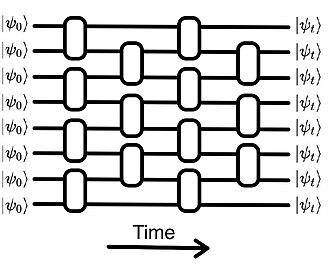

*This is a quantum circuit diagram showing 8 qubits at time t=0 on the left side undergoing some unitary gates (the white boxes) as time goes on to give some final state. (source: https://en.wikipedia.org/wiki/Quantum_random_circuits)*

This allows us to track the growth of entanglement of the system. We will use this second model to compute the entanglement entropy value at large time and compare it with the mean entanglement entropy computed using RMT.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cmath
import scipy

j=complex(0,1) # imaginary unit

## Simulation using RMT

In this short simulation, we will simulate a chain of $N$ spin 1/2 (or qubits). We will consider only even values of $N$. The wave function takes the general form:
$$ \sum_{\sigma_1=\{0,1\}} ... \sum_{\sigma_N=\{0,1\}}  \psi_{\sigma_1 ... \sigma_N} \ket{\sigma_1 ... \sigma_N}$$

To generate the random wave functions that we will need, we assumed all the coefficients $\psi_{\sigma_1 ... \sigma_N}$ are independent and identically distributed. The function ```random_state(N)``` returns a list containing the $2^N$ random coefficients:

In [2]:
def random_state(N):
    
    # Generate a random amplitude for each coordinate:
    Amp=np.random.rand(2**N)
    
    # Normalize the amplitudes:
    Amp=Amp/np.linalg.norm(Amp) 

    # Generate a random phase for each coordinate:
    Phase=np.random.rand(2**N)*2*np.pi
    
    # Combine the amplitude and phase to get the complex coefficients:
    Coeff=Amp*np.exp(j*Phase) 
    
    # Reshape the coefficients into a 2^(N/2) x 2^(N/2) matrix:
    Coeff=np.reshape(Coeff,(2**(N//2),2**(N//2)))
    
    return Coeff

The theoretical value for the maximal entropy of a chain of spins can be obtained by partitioning the full Hilbert space into two equal halves: the left N/2 spins denoted by L and the right N/2 spins denoted by R. This allows us to write the wave state as:

$$\ket{\psi}=\sum_\alpha \lambda_\alpha \ket{\alpha}_L \otimes \ket{\alpha}_R$$

where we have used the Schmidt decomposition.

We can show that the maximal entanglement entropy is therefore $S=\frac{N}{2}\log(2)$.

Below is a program plotting the histogram of the entanglement entropy of ``N_iter`` samples for $4$ and $10$ spins and comparing it with the maximal value:

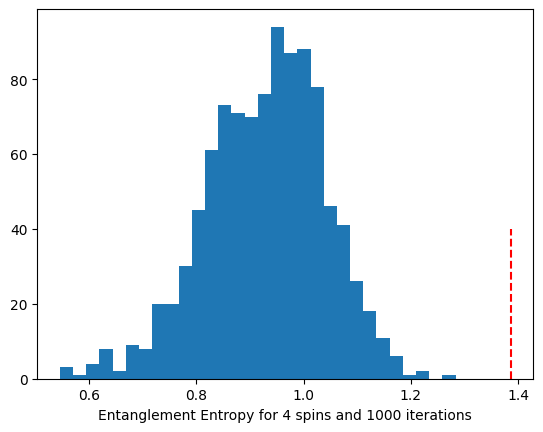

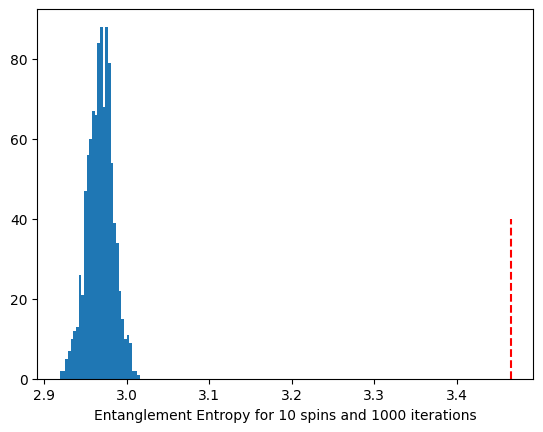

In [3]:

# Number of spins in the system (Hilbert space has dimension 2^N)
N_list=[4,10]  

# Number of random states to generate
N_iter=1000 

for N in N_list:
    # Array to store the entropies
    Entropies=[] 

    for i in range(N_iter):
        # Generate a random state
        Coeff=random_state(N) 
        
        # Singular value decomposition of the coefficient matrix
        _,L,_=np.linalg.svd(Coeff) 
        
        # Von Neumann entropy
        S=-np.sum(L**2*np.log(L**2)) 
        
        Entropies.append(S)

    # Plot
    plt.hist(Entropies,bins=30)
    plt.vlines(N//2*np.log(2),0,40,colors='r',linestyles='dashed',label='Expected Value')
    plt.xlabel(f'Entanglement Entropy for {N} spins and {N_iter} iterations'.format(N=N))
    plt.show()



We now average the entropy on ``N_iter`` values and plot this mean for different number of spins with errorbars:

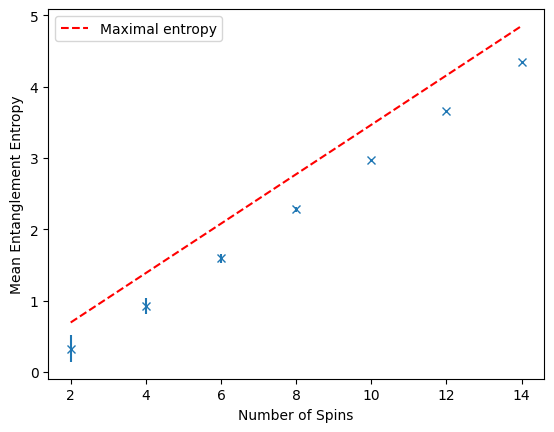

In [4]:
# List of N values to iterate over
List_N=np.linspace(2,14,7,dtype=int) 

# Number of random states to generate
N_iter=1000 

# Array to store the mean entropies
Entropies_mean=[] 

# Array to store the standard deviation of the entropies
Error_bars=[] 

for N in List_N:

    # Array to store the entropies for each N
    Entropies=[] 

    for i in range(N_iter):

        # Generate a random state
        Coeff=random_state(N) 
        
        # Singular value decomposition of the coefficient matrix
        _,L,_=np.linalg.svd(Coeff) 

        # Von Neumann entropy
        S=-np.sum(L**2*np.log(L**2)) 

        Entropies.append(S)
      
    
    Entropies_mean.append(np.mean(Entropies))
    Error_bars.append(np.std(Entropies))

#Plot
plt.errorbar(List_N,Entropies_mean,yerr=Error_bars,fmt='x')
plt.plot(List_N,np.log(2**(List_N//2)),'r--',label='Maximal entropy')
plt.xlabel('Number of Spins')
plt.ylabel('Mean Entanglement Entropy')
plt.legend()



## Simulation using a random unitary circuit

Our goal is to compare the previous plot with the evolution of $S_{\infty}$ with the number of spins where $S_{\infty}$ refers to the entropy of the system going through the unitary circuit after a large time. 

On the circuit, we will use single two-qubits unitary operators $\hat{U}$ which will be taken from the Circular Unitary Ensemble (CUE). 

Below, we first plot the distribution (histogram over ``N_iter`` samples) of entanglement entropy of two qubits over the CUE, starting from a product state $\ket{\psi_0}$:

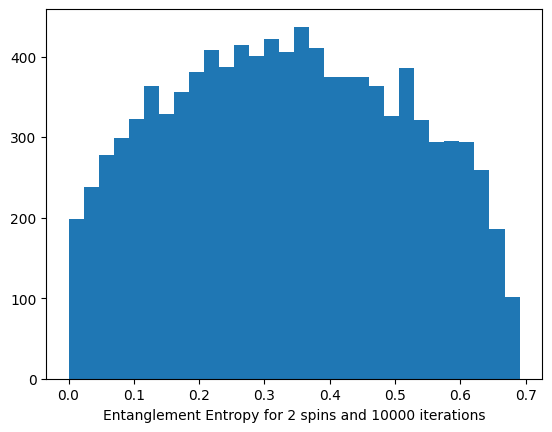

In [5]:
# Number of samples:
N_iter=10000

# Initial state vector for 2 spins (product state)
psi_0=np.array([[1],[0],[0],[0]],dtype=complex) 

# Vector to store the entropies of each sample:
Entropies=[]

for i in range(N_iter):

    # Generate a random 4x4 unitary matrix
    U = scipy.stats.unitary_group.rvs(4)

    # Apply the unitary transformation
    psi = np.dot(U, psi_0)

    # Density matrix of the state
    rho=np.dot(psi,psi.conj().T) 

    # Reshape the 4x4 matrix to a tensor with 4 indices (2 for each subsystem)
    rho=rho.reshape(2,2,2,2) 

    # Reduced density matrix for subsystem A (trace over subsystem B)
    rho_A=np.trace(rho,axis1=1,axis2=3) 

    # Computing entanglement entropy:
    eigvals = np.linalg.eigvalsh(rho_A) 

    S = -np.sum(eigvals * np.log(eigvals))

    # Storage:
    Entropies.append(S)


# Plotting the histogram of entropies:
plt.hist(Entropies,bins=30)

plt.xlabel(f'Entanglement Entropy for 2 spins and {N_iter} iterations'.format(N=2))

plt.show()


The next step before simulating our random unitary circuit is to create a function ``random_unitary_layer(U,psi,i,j)`` that applies the unitary matrix ``U`` on the spins bond ``(i,j)`` of the state ``psi``: 

In [6]:
def random_unitary_layer(U,psi,i,j):
       
    # Reshape the unitary matrix to act on two qubits
    U=np.reshape(U,(2,2,2,2)) 

    # Applying the tensor product:
    psi = np.tensordot(U, psi, axes=([0,1],[i,j]))

    return psi

We now take a chain of L qubits/spins. Again we start from a product state $\ket{\psi_0}$. 

Now a single time step consist of one layer of unitary 2-qubit gates on every odd bond, followed by a layer of unitary 2-qubit gates on every 2 even bond. Every unitary in this circuit is random and independent. This gives $\ket{\psi_1}$. Repeating $t$ times gives $\ket{\psi(t)}$ where $t$ is an integer.

The program below plots the entanglement entropy versus time on ``N_iter=20`` samples for $4, 8$ and $14$ spins:

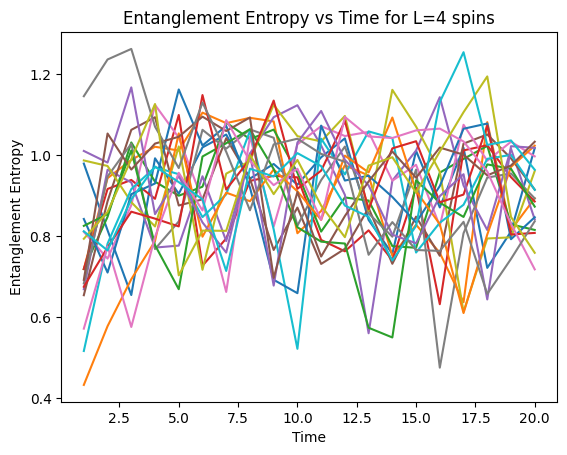

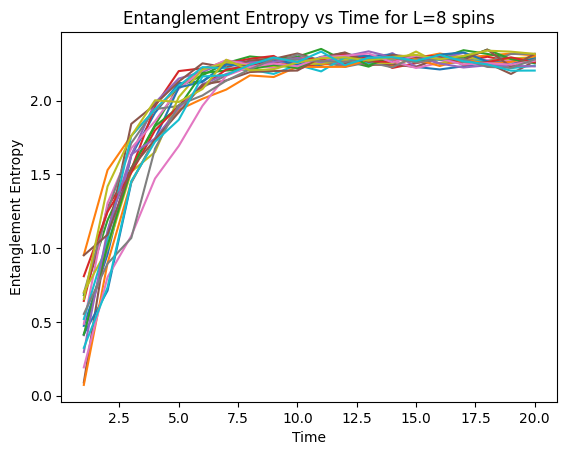

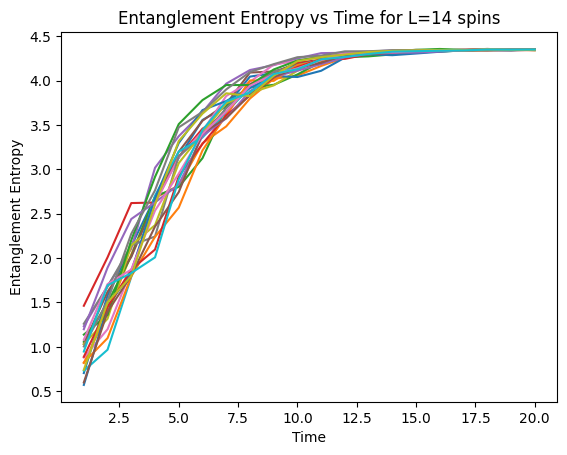

In [7]:
# Number of spins:
L_list=[4,8,14]

# Maximum time steps:
t=20

# Time array for plotting
T=np.linspace(1,t,t) 

#Number of different iterations for a given L and t:
N_iter=20


for L in L_list:
    for k in range(N_iter):

        # List to store the entropies at each time step
        S_t=[] 

        # Initial state vector for L spins 
        psi_0=np.zeros((2**L,1),dtype=complex) 

        # Set the first element to 1 to create a product state
        psi_0[0]=1 

        # Representing the wave function as a tensor with L indices:
        psi = psi_0.reshape([2]*L)

        # Applying the layers of unitary transformations...
        for time in range(t):

            i,j=0,1

            #...on odd edges:
            while i<L-1:
                
                U = scipy.stats.unitary_group.rvs(4)

                psi = random_unitary_layer(U,psi,i,i+1)
            
                i += 2

            #...on even edges:
            while j<L-1:

                U = scipy.stats.unitary_group.rvs(4)
                
                psi = random_unitary_layer(U,psi,j,j+1)

                j += 2

            # Calculate the half-chain entanglement entropy using SVD:
            psi_mat = psi.reshape(2**(L//2), 2**(L//2))
            
            _,Sigma,_=np.linalg.svd(psi_mat) 
        
            S=-np.sum(Sigma**2*np.log(Sigma**2)) 

            # Adding value to the storing list:
            S_t.append(S)

        # Plotting iteration k+1 for a given L:
        plt.plot(T,S_t,label=f'Iteration {k+1}')



    # Graph parameters for a given L:
    plt.xlabel('Time')

    plt.ylabel('Entanglement Entropy')

    plt.title(f'Entanglement Entropy vs Time for L={L} spins')
    
    plt.show()

Finally, we plot $S_{\infty}$ versus number of spins and compare our results with the mean entanglement entropy obtained previously using random matrix theory prediction. $S_{\infty}$ is obtained by taking the value at time ``t=20`` averaged on ``N_iter=50`` iterations:

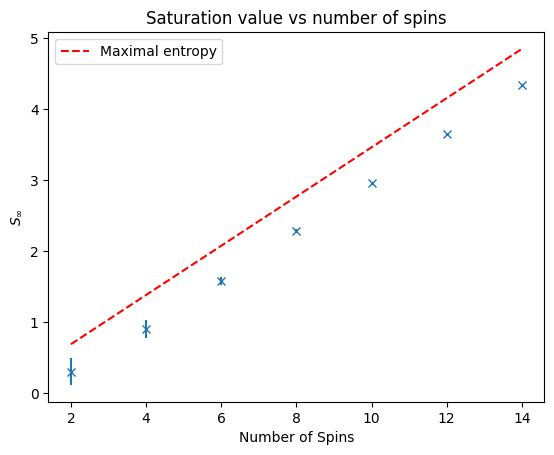

In [8]:
#Number of spins:
L_list=np.linspace(2,14,7,dtype=int)

#Maximum time steps:
t=20
T=np.linspace(1,t,t) # time array for plotting

#Number of different iterations for a given L and t:
N_iter=50

#List to store S_inf for each L:
S_L=[]
Err_bars=[]

for L in L_list:

    #List to store S_inf for each iteration at a given L:
    S_k=[]

    for k in range(N_iter):

        # Initial state vector for L spins 
        psi_0=np.zeros((2**L,1),dtype=complex) 

        # Set the first element to 1 to create a product state
        psi_0[0]=1 

        # Representing the wave function as a tensor with L indices:
        psi = psi_0.reshape([2]*L)

        # Applying the layers of unitary transformations...
        for time in range(t):

            i,j=0,1

            #...on odd edges:
            while i<L-1:
                
                U = scipy.stats.unitary_group.rvs(4)

                psi = random_unitary_layer(U,psi,i,i+1)
            
                i += 2

            #...on even edges:
            while j<L-1:

                U = scipy.stats.unitary_group.rvs(4)
                
                psi = random_unitary_layer(U,psi,j,j+1)

                j += 2

            # Adding value to the storing list:
            if time==t-1:

                #Calculate the half-chain entanglement entropy using SVD:
                psi = psi.reshape(2**(L//2), 2**(L//2))
                
                _,Sigma,_=np.linalg.svd(psi) 
            
                S=-np.sum(Sigma**2*np.log(Sigma**2)) 

                S_k.append(S)

    S_L.append(np.mean(S_k))
    Err_bars.append(np.std(S_k))





#Plotting S_inf vs L:
plt.errorbar(L_list,S_L,yerr=Err_bars,fmt='x')

plt.plot(L_list,np.log(2**(L_list//2)),'r--',label='Maximal entropy')

plt.ylabel(r'$S_{\infty}$')

plt.xlabel('Number of Spins')

plt.title(f'Saturation value vs number of spins')

plt.legend()


Compared with the graph plotted using the random matrix theory:

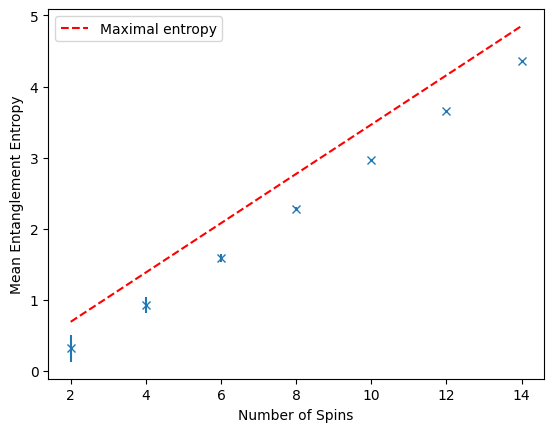

## Conclusion

In conclusion, we managed to compute the mean entanglement entropy of a chain of spins with different lengths using RMT. The random unitary circuit allowed us to progressively grow the entanglement entropy of our chain with starts to stabilize at large times (logarithmic-like curve) taking the value after 20 iterations have proven to be sufficient to reproduce the RMT results. 

This simple exercise is a great example on how to diffrent simple methods can lead to the same results without over-complexed algorithms (execution time less than a minute).